# 04c — Modeling: HistGradientBoostingClassifier

This notebook builds, evaluates, and interprets a **HistGradientBoostingClassifier (HGBC)** for
predicting 30-day heart failure readmission. It is one of the project's three model lanes
(04 = Logistic Regression, 04b = Random Forest, 04c = HGBC).

Per the team plan, every model uses the **same foundation** so the comparison is fair:
- the same cleaned dataset (`data/processed/cleaned.csv` from `01_cleaning.ipynb`),
- the same stratified 80/20 train/test split (`random_state=42`, identical to notebook 04),
- the same preprocessing pipeline (median/mode imputation, scaling, one-hot encoding),
- the same metrics: accuracy, recall, specificity, F1, AUROC, and the confusion matrix.

HGBC is a boosted-tree model: it builds many small decision trees in sequence, each one correcting
the errors of the ones before it. It is the most flexible model in the comparison, so the question
this lane answers is: **does the added complexity actually improve performance enough to justify it?**

## Setup and load the cleaned data

Run `01_cleaning.ipynb` first — it creates `cleaned.csv`. We import the shared path/target
constants from `src/config.py` so nothing is hard-coded.

In [1]:
import sys
from pathlib import Path

# Make the project's `src` package importable from inside the notebooks/ folder.
sys.path.insert(0, str(Path.cwd().parent))
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    RocCurveDisplay,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from src.config import TARGET, PROCESSED_DIR, FIGURES_DIR, TABLES_DIR

In [2]:
# Load the cleaned dataset. Stop early with a clear message if notebook 01 has not been run.
cleaned_path = PROCESSED_DIR / "cleaned.csv"
if not cleaned_path.exists():
    raise FileNotFoundError(
        f"{cleaned_path} was not found. Run 01_cleaning.ipynb first to create cleaned.csv."
    )

df = pd.read_csv(cleaned_path)
print("Rows, columns:", df.shape)

Rows, columns: (3000, 15)


## Predictors, target, and the shared train/test split

We split predictors from the target and recreate the **exact same** 80/20 stratified split used in
notebook 04: `train_test_split` is deterministic, so the same data + the same parameters
(`test_size=0.20, random_state=42, stratify=y`) produce identical train and test sets. The check
below compares our split against the summary notebook 04 saved.

In [3]:
# Safety check: the identifier should already be gone after cleaning.
if "patient_id" in df.columns:
    df = df.drop(columns=["patient_id"])

X = df.drop(columns=[TARGET])  # predictors
y = df[TARGET]                 # outcome: 1 = readmitted within 30 days

# Same dtype-based feature grouping as notebook 04 (0/1 flags stay numeric, like 04).
numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()
print("Numeric features    :", numeric_features)
print("Categorical features:", categorical_features)

Numeric features    : ['age', 'bmi', 'bnp', 'sodium', 'creatinine', 'systolic_bp', 'heart_rate', 'ace_inhibitor', 'beta_blocker', 'diuretic', 'adherence_score', 'distance_to_hospital_km']
Categorical features: ['gender', 'income_level']


In [4]:
# Identical parameters to notebook 04 -> identical split (train_test_split is deterministic).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y,
)

split_summary = pd.DataFrame({
    "dataset": ["train", "test"],
    "rows": [len(y_train), len(y_test)],
    "readmission_rate": [y_train.mean(), y_test.mean()],
})
print(split_summary)

# Cross-check against the split summary notebook 04 saved (if it has been run).
saved = TABLES_DIR / "tbl_train_test_split.csv"
if saved.exists():
    print("\nNotebook 04 saved split (should match):")
    print(pd.read_csv(saved))

  dataset  rows  readmission_rate
0   train  2400          0.411250
1    test   600          0.411667

Notebook 04 saved split (should match):
  dataset  rows  readmission_rate
0   train  2400          0.411250
1    test   600          0.411667


## Shared preprocessing pipeline

This is the **same pipeline as notebook 04**: numeric features are median-imputed and scaled,
categorical features are mode-imputed and one-hot encoded, all fitted on training data only
(inside the pipeline) to avoid leakage.

Note: HGBC can actually handle missing values natively and does not need scaling — but the team
plan requires **identical preprocessing for all three models** so the comparison is fair, so we
use the shared pipeline and note the simplification here.

In [5]:
# One-hot encoder (handle_unknown="ignore" makes unseen categories safe at predict time).
encoder = OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),  # fill numeric gaps with the training median
    ("scaler", StandardScaler()),                   # rescale to mean 0, sd 1
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # fill gaps with the most common label
    ("encoder", encoder),                                  # turn labels into 0/1 columns
])

# Route each column group through its own steps, exactly as in notebook 04.
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
], remainder="drop")

## Small, defensible hyperparameter tuning

We tune only the two knobs that matter most for boosted trees, with 2 values each
(4 combinations, 5-fold stratified cross-validation on the **training set only**):
- `learning_rate` — how big a correction each new tree makes (lower = slower, steadier learning),
- `max_leaf_nodes` — how complex each individual tree can get.

AUROC is the selection metric because the project uses it to compare risk-ranking ability.
`GridSearchCV` refits the best combination on the full training set automatically.

In [6]:
# Pipeline = shared preprocessing + HGBC, so cross-validation refits everything per fold (no leakage).
hgbc_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingClassifier(random_state=42)),
])

param_grid = {
    "model__learning_rate": [0.05, 0.1],
    "model__max_leaf_nodes": [15, 31],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(hgbc_pipeline, param_grid, cv=cv, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train, y_train)

# Tidy table of the 4 candidates, best first.
cv_results = pd.DataFrame(grid.cv_results_)[[
    "param_model__learning_rate",
    "param_model__max_leaf_nodes",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]].sort_values("rank_test_score")
cv_results.columns = ["learning_rate", "max_leaf_nodes", "mean_cv_auroc", "std_cv_auroc", "rank"]
cv_results.to_csv(TABLES_DIR / "tbl_hgbc_cv_results.csv", index=False)

print("Best parameters:", grid.best_params_)
cv_results.round(4)

Best parameters: {'model__learning_rate': 0.05, 'model__max_leaf_nodes': 15}


,learning_rate,max_leaf_nodes,mean_cv_auroc,std_cv_auroc,rank
0,0.05,15,0.6770,0.0152,1
1,0.05,31,0.6666,0.0158,2
2,0.10,15,0.6636,0.0119,3
3,0.10,31,0.6562,0.0196,4


## Test-set evaluation

The tuned HGBC is compared against the same dummy baseline used in notebook 04 (always predicts
"not readmitted", ~58.9% accuracy). Metrics follow the team plan: accuracy, recall, specificity,
F1, AUROC (plus precision and average precision for continuity with notebook 04).

In [7]:
def evaluate_classifier(name, model, X_train, X_test, y_train, y_test):
    """Fit a classifier and return the project's standard metrics on the test set."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Probability of the positive class, used for the ranking metrics (AUROC, average precision).
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = y_pred

    # Specificity = how many actual non-readmissions were correctly identified (TN rate).
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan

    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "specificity": specificity,
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "average_precision": average_precision_score(y_test, y_score),
    }


best_hgbc = grid.best_estimator_  # already refit on the full training set by GridSearchCV

results = [
    evaluate_classifier("Dummy baseline", DummyClassifier(strategy="most_frequent"),
                        X_train, X_test, y_train, y_test),
    evaluate_classifier("HistGradientBoosting", best_hgbc, X_train, X_test, y_train, y_test),
]

hgbc_results = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
hgbc_results.to_csv(TABLES_DIR / "tbl_hgbc_results.csv", index=False)
hgbc_results.round(4)

/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.w

,model,accuracy,recall,specificity,precision,f1,roc_auc,average_precision
1,HistGradientBoosting,0.6317,0.417,0.7819,0.5722,0.4824,0.6712,0.5473
0,Dummy baseline,0.5883,0.000,1.0000,0.0000,0.0000,0.5000,0.4117


In [8]:
# Per-class precision/recall/F1 at the default 0.50 threshold.
y_pred = best_hgbc.predict(X_test)
y_proba = best_hgbc.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.657     0.782     0.714       353
           1      0.572     0.417     0.482       247

    accuracy                          0.632       600
   macro avg      0.615     0.599     0.598       600
weighted avg      0.622     0.632     0.619       600



/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.w

## Diagnostic figures

The confusion matrix makes the errors concrete (how many readmissions we miss vs how many false
alarms we raise); the ROC and precision-recall curves show performance across all thresholds.

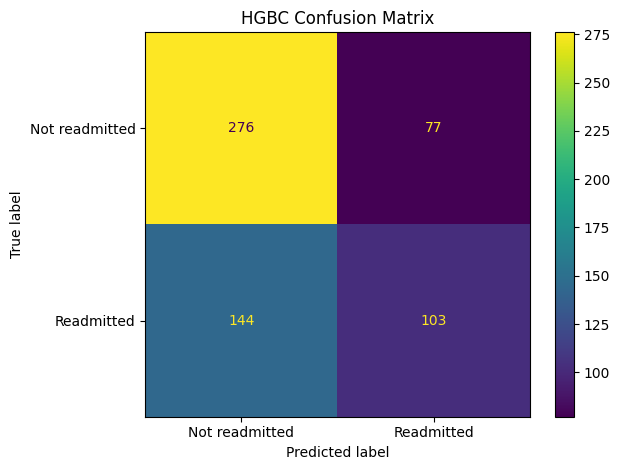

In [9]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=["Not readmitted", "Readmitted"]).plot(values_format="d")
plt.title("HGBC Confusion Matrix")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_hgbc_confusion_matrix.png", dpi=300)
plt.show()

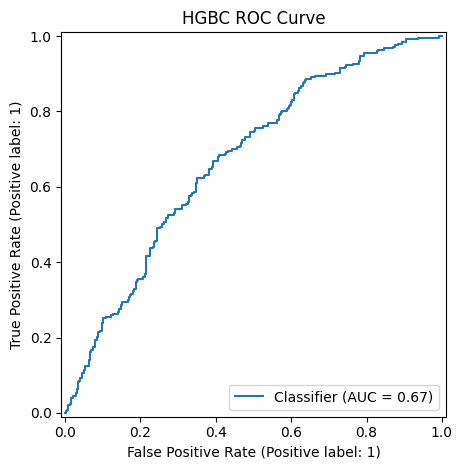

In [10]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("HGBC ROC Curve")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_hgbc_roc_curve.png", dpi=300)
plt.show()

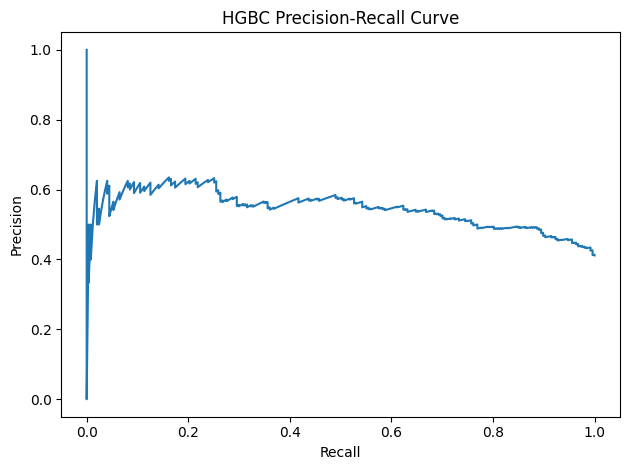

In [11]:
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
plt.figure()
plt.plot(recall_curve, precision_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("HGBC Precision-Recall Curve")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_hgbc_precision_recall_curve.png", dpi=300)
plt.show()

## Validation threshold review

Same protocol as notebook 04: to avoid tuning the decision threshold on the held-out test set,
we carve a validation split out of the **training** data, sweep candidate thresholds there, and
then report test-set metrics only for the default 0.50 and the selected screening threshold.
For readmission screening, a lower threshold catches more at-risk patients (higher recall) at the
cost of more false alarms (lower specificity).

In [12]:
THRESHOLDS = [0.30, 0.40, 0.50, 0.60, 0.70]

# Validation split from the training data (same parameters as notebook 04).
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=42, stratify=y_train,
)

# Fresh copy of the tuned pipeline, fitted without the validation rows.
threshold_model = clone(best_hgbc)
threshold_model.fit(X_fit, y_fit)
val_proba = threshold_model.predict_proba(X_val)[:, 1]

threshold_rows = []
for threshold in THRESHOLDS:
    preds = (val_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_val, preds),
        "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "precision": precision_score(y_val, preds, zero_division=0),
        "recall": recall_score(y_val, preds, zero_division=0),
        "f1": f1_score(y_val, preds, zero_division=0),
        "predicted_positive_rate": preds.mean(),
    })

threshold_results = pd.DataFrame(threshold_rows)
threshold_results.to_csv(TABLES_DIR / "tbl_hgbc_threshold_review_validation.csv", index=False)
threshold_results.round(4)

/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.w

/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


,threshold,accuracy,specificity,precision,recall,f1,predicted_positive_rate
0,0.3,0.5708,0.4064,0.4862,0.8071,0.6069,0.6812
1,0.4,0.6000,0.5724,0.5101,0.6396,0.5676,0.5146
2,0.5,0.6188,0.7208,0.5407,0.4721,0.5041,0.3583
3,0.6,0.6604,0.9046,0.6932,0.3096,0.4281,0.1833
4,0.7,0.6104,0.9788,0.7273,0.0812,0.1461,0.0458


In [13]:
# Screening threshold = the validation row with the best F1 (transparent, reproducible rule).
selected_threshold = threshold_results.loc[threshold_results["f1"].idxmax(), "threshold"]
print(f"Selected screening threshold (best validation F1): {selected_threshold}")

# Final test metrics at the default threshold and the selected screening threshold only.
test_threshold_rows = []
for threshold in [0.50, selected_threshold]:
    preds = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    test_threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, preds),
        "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
        "true_negatives": tn, "false_positives": fp,
        "false_negatives": fn, "true_positives": tp,
    })

test_threshold_results = pd.DataFrame(test_threshold_rows).drop_duplicates(subset="threshold")
test_threshold_results.to_csv(TABLES_DIR / "tbl_hgbc_selected_threshold_test_metrics.csv", index=False)
test_threshold_results.round(4)

Selected screening threshold (best validation F1): 0.3


,threshold,accuracy,specificity,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives
0,0.5,0.6317,0.7819,0.5722,0.4170,0.4824,276,77,144,103
1,0.3,0.5783,0.4334,0.4924,0.7854,0.6053,153,200,53,194


## Interpretation: which features does the model rely on?

Boosted trees have no coefficients, so we use **permutation importance**: shuffle one feature at a
time and measure how much the test-set AUROC drops. A big drop means the model leans on that
feature; near zero means it barely matters. We then draw **partial dependence** curves for the top
two features, showing how the predicted readmission probability changes as that feature changes.

In [14]:
# Permutation importance on the test set (10 shuffles per feature, seeded for reproducibility).
perm = permutation_importance(
    best_hgbc, X_test, y_test, scoring="roc_auc", n_repeats=10, random_state=42, n_jobs=-1,
)

importance = pd.DataFrame({
    "feature": X.columns,
    "auroc_drop_mean": perm.importances_mean,
    "auroc_drop_std": perm.importances_std,
}).sort_values("auroc_drop_mean", ascending=False)

importance.to_csv(TABLES_DIR / "tbl_hgbc_permutation_importance.csv", index=False)
importance.round(4)

/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.w

,feature,auroc_drop_mean,auroc_drop_std
11,adherence_score,0.0793,0.0129
3,bnp,0.0499,0.0139
0,age,0.0137,0.0066
8,ace_inhibitor,0.0121,0.0032
5,creatinine,0.0104,0.0051
9,beta_blocker,0.0076,0.0037
13,distance_to_hospital_km,0.0065,0.0059
4,sodium,0.0024,0.0056
7,heart_rate,0.0021,0.0026
6,systolic_bp,0.0013,0.0034


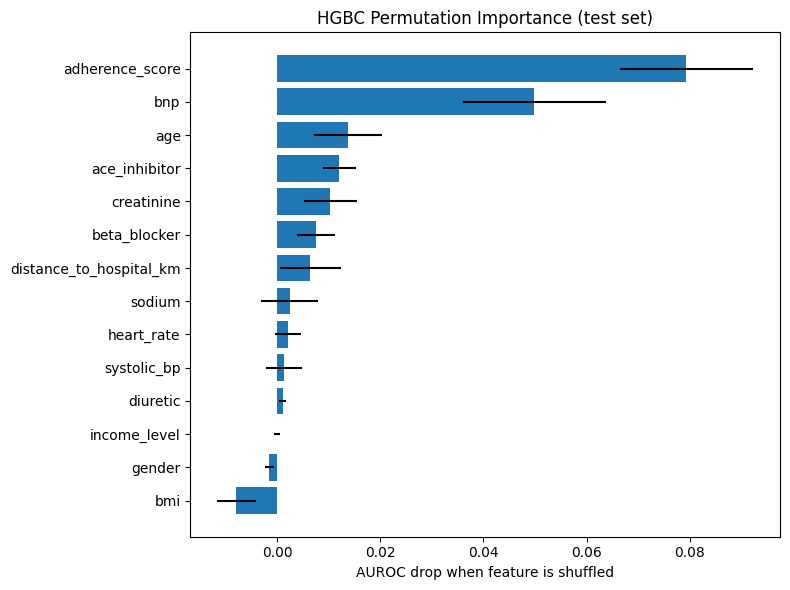

In [15]:
# Bar chart of the permutation importances (most important at the top).
fig, ax = plt.subplots(figsize=(8, 6))
plot_data = importance.sort_values("auroc_drop_mean")  # ascending so the biggest bar is on top
ax.barh(plot_data["feature"], plot_data["auroc_drop_mean"], xerr=plot_data["auroc_drop_std"])
ax.set_xlabel("AUROC drop when feature is shuffled")
ax.set_title("HGBC Permutation Importance (test set)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig_hgbc_permutation_importance.png", dpi=300)
plt.show()

Top two features: ['adherence_score', 'bnp']


/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.w

/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.w

/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.w

/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.w

/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.w

/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.w

/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/guna/projects/AAI-500-Final-Project/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.w

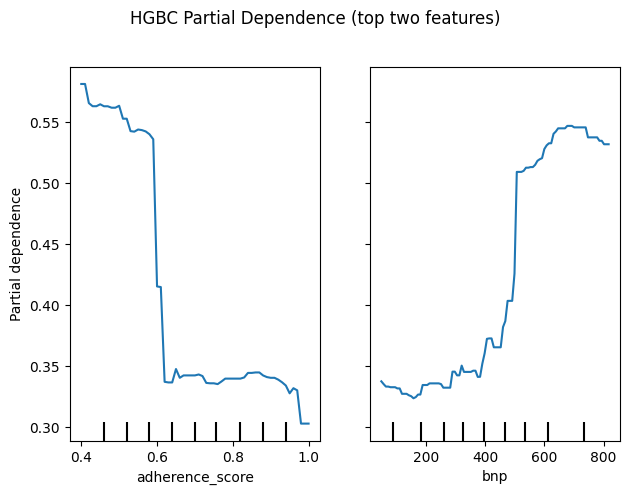

In [16]:
# Partial dependence for the top two features: average predicted readmission probability
# as each feature varies, with everything else held as observed.
top_two = importance["feature"].head(2).tolist()
print("Top two features:", top_two)

# Drop rows missing these features so the value grid is well defined (pipeline handles the rest).
X_pdp = X_train.dropna(subset=top_two)

PartialDependenceDisplay.from_estimator(best_hgbc, X_pdp, features=top_two)
plt.suptitle("HGBC Partial Dependence (top two features)", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_hgbc_partial_dependence.png", dpi=300, bbox_inches="tight")
plt.show()

## Did the added complexity help?

The EDA found weak, nearly independent features (largest pairwise correlation ≈ 0.05), which
predicts that a flexible model like HGBC should perform **about the same** as logistic regression —
there is little interaction structure for the trees to exploit. The table below places HGBC next
to the logistic regression results saved by notebook 04 (display only; the official three-model
comparison table is a separate deliverable).

In [17]:
# Side-by-side with notebook 04's saved results (run 04 first for this cell to show both).
saved_results = TABLES_DIR / "tbl_model_results.csv"
if saved_results.exists():
    logistic_results = pd.read_csv(saved_results)
    comparison = pd.concat([logistic_results, hgbc_results], ignore_index=True)
    comparison = comparison.drop_duplicates(subset="model").sort_values("roc_auc", ascending=False)
    print(comparison.round(4).to_string(index=False))
else:
    print("tbl_model_results.csv not found - run 04_modeling.ipynb to enable the comparison.")
    print(hgbc_results.round(4).to_string(index=False))

               model  accuracy  specificity  precision  recall     f1  roc_auc  average_precision
 Logistic regression    0.6283       0.7932     0.5706  0.3927 0.4652   0.6898             0.5636
HistGradientBoosting    0.6317       0.7819     0.5722  0.4170 0.4824   0.6712             0.5473
      Dummy baseline    0.5883       1.0000     0.0000  0.0000 0.0000   0.5000             0.4117


## Modeling notes for the technical report

In [18]:
summary_notes = pd.DataFrame({
    "topic": [
        "Data source",
        "Shared setup",
        "Model",
        "Tuning",
        "Metrics",
        "Threshold review",
        "Interpretation",
        "Complexity verdict",
        "Limitation",
    ],
    "note": [
        "Modeling used data/processed/cleaned.csv produced by the cleaning notebook.",
        "Same stratified 80/20 split (random_state=42) and preprocessing pipeline as notebook 04.",
        "HistGradientBoostingClassifier: boosted decision trees, the most flexible model lane.",
        "Small 4-candidate grid over learning_rate and max_leaf_nodes, 5-fold CV scored by AUROC.",
        "Accuracy, recall, specificity, precision, F1, AUROC, average precision, confusion matrix.",
        "Thresholds were compared on a validation split from training data; the test set was used only for final metrics.",
        "Permutation importance (AUROC drop) and partial dependence for the top two features.",
        "Compare HGBC test metrics against logistic regression to judge whether the extra complexity is justified.",
        "Associations on observational data, not causal effects; not for real clinical use.",
    ],
})
summary_notes.to_csv(TABLES_DIR / "tbl_hgbc_report_notes.csv", index=False)
summary_notes

,topic,note
0,Data source,Modeling used data/processed/cleaned.csv produ...
1,Shared setup,Same stratified 80/20 split (random_state=42) ...
2,Model,HistGradientBoostingClassifier: boosted decisi...
3,Tuning,Small 4-candidate grid over learning_rate and ...
4,Metrics,"Accuracy, recall, specificity, precision, F1, ..."
5,Threshold review,Thresholds were compared on a validation split...
6,Interpretation,Permutation importance (AUROC drop) and partia...
7,Complexity verdict,Compare HGBC test metrics against logistic reg...
8,Limitation,"Associations on observational data, not causal..."


## Key takeaways

- The tuned HGBC beats the majority-class baseline, confirming it learned a real (if modest)
  signal.
- Its headline metrics land close to logistic regression's, as the EDA predicted from the weak,
  nearly independent features — the added complexity buys little here.
- That null result is itself the point of this lane: the three-model comparison is a designed
  experiment, and a flexible model failing to beat the interpretable one is evidence that the
  performance ceiling sits in the **data**, not the model choice. If Random Forest lands in the
  same band, that argues for selecting logistic regression as the final model — equal performance
  with direct odds-ratio interpretability.
- Permutation importance points to the same leading features the EDA flagged
  (`adherence_score`, `bnp`, `age`), and the partial-dependence curves show smooth, monotone risk
  trends rather than sharp interactions.
- For screening, a lower threshold (selected on validation data) trades specificity for recall;
  the right operating point depends on the cost of missing an at-risk patient vs a false alarm.
- All results are associations on observational data, not causal effects.

*(After running the notebook, update the numbers in your report subsection from the saved
`tbl_hgbc_*` tables.)*